In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio

## 1. Frequency domain BF: Different directions

In [12]:
def shift_signal(signal, t):
    sampling_rate = signal.shape[0]
    shift = int(t*sampling_rate)
    shifted_sig = np.roll(signal, shift)
    if shift > 0:
        shifted_sig[:shift] = 0
    elif shift < 0:
        shifted_sig[shift:] = 0
    return shifted_sig
    
def wft(f1, f2, a1, a2, theta, title):
    t = 1
    fsample = 110000
    samples = np.linspace(0, t, fsample)
    freq1 = f1
    freq2 = f2
    sig3_1 = a1*np.sin(2*np.pi*freq1*samples)
    sig3_2 = a2*np.sin(2*np.pi*freq2*samples)
    tp = 3*int(fsample / max(freq1, freq2))
    
    sig3 = sig3_1 + sig3_2

    # Array response
    d = 0.3
    c0 = 340
    
    tpi = int((fsample/(t*max(freq1, freq2)))*5)
    tpf = int((fsample/(t*max(freq1, freq2)))*10)
    
    fig, ax = plt.subplots(figsize = (8, 4))
    p2 = 0.5*d*np.sin(theta*np.pi/180)/c0
    p1 = d*np.sin(theta*np.pi/180)/c0
    sig2a = shift_signal(sig3, p2)
    sig1a = shift_signal(sig3, p1)
    sig = sig1a + sig2a + sig3
    ax.plot(samples[tpi:tpf], sig3[tpi:tpf], label = '3', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = '1', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = '2', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig[tpi:tpf], label = 'Array', alpha = 0.7, color = 'purple')
    ax.legend()
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (s)")
    # ax.set_ylim([-1.5, 1.5])
    ax.axhline(0, color = 'grey', lw = 0.7)
    ax.set_title(f'Wavefront {title} angle: {theta}deg')
    plt.show(fig)
    plt.close(fig)

    return [sig1a, sig2a, sig3], samples, fig

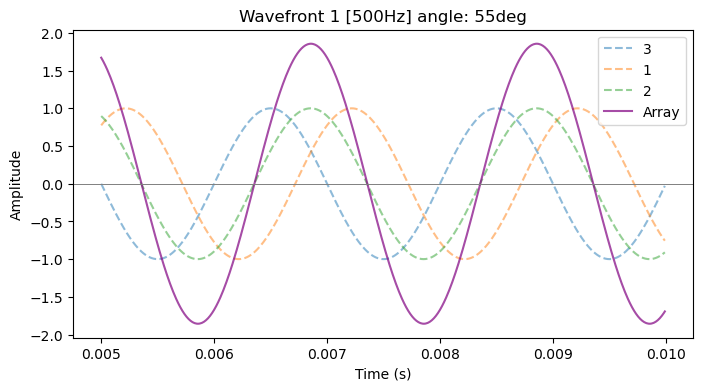

In [14]:
siga1, samples, fig1 = wft(500, 1000, 1, 0, 55, '1 [500Hz]')
# fig1.savefig('Signal1_DF.png')

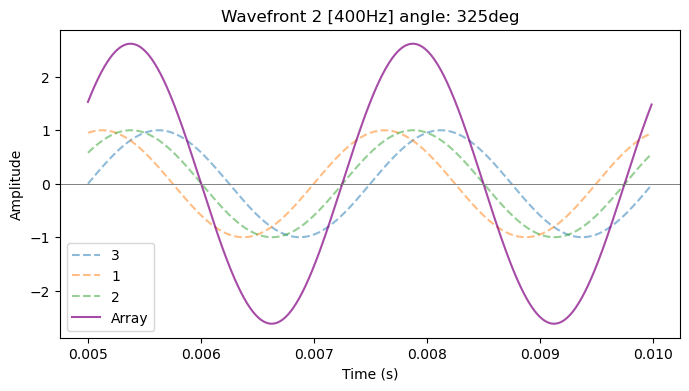

In [16]:
siga2, samples, fig2 = wft(400, 1000, 1, 0, 325, '2 [400Hz]')
# fig2.savefig('Signal2_DF.png')

Text(0.5, 0, 'Time (s)')

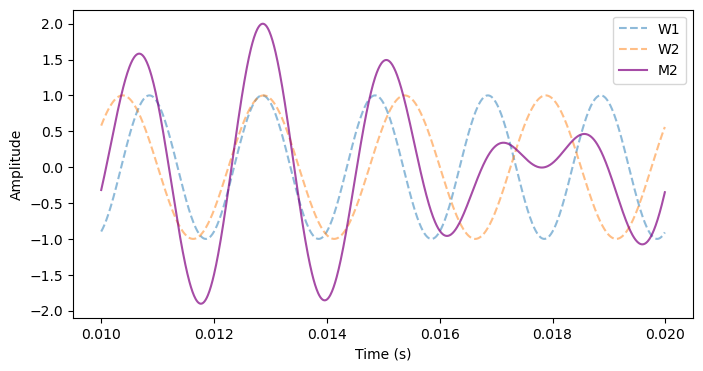

In [22]:
# Mic2
fsample = 110000
t = 1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig2a = siga1[1] + siga2[1]
ax.plot(samples[tpi:tpf], siga1[1][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[1][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = 'M2', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# fig.savefig('DF_M2.png')

Text(0.5, 0, 'Time (s)')

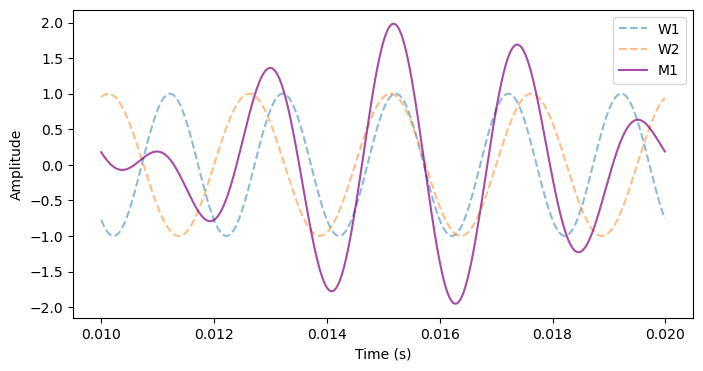

In [24]:
# Mic1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig1a = siga1[0] + siga2[0]
ax.plot(samples[tpi:tpf], siga1[0][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[0][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = 'M1', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# fig.savefig('DF_M1.png')

Text(0.5, 0, 'Time (s)')

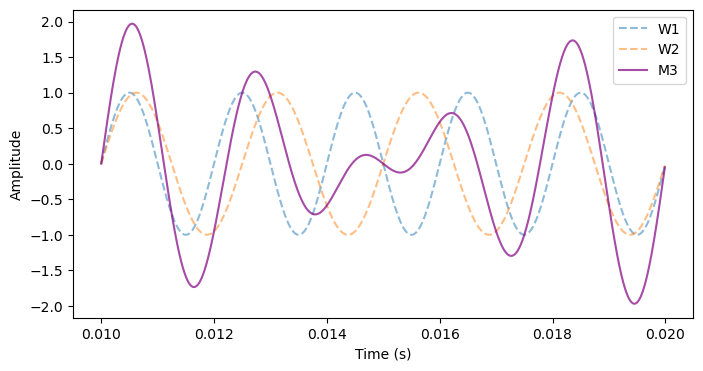

In [26]:
#Mic 3
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig3a = siga1[2] + siga2[2]
ax.plot(samples[tpi:tpf], siga1[2][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[2][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig3a[tpi:tpf], label = 'M3', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# fig.savefig('DF_M3.png')

Text(0.5, 1.0, 'Total array response')

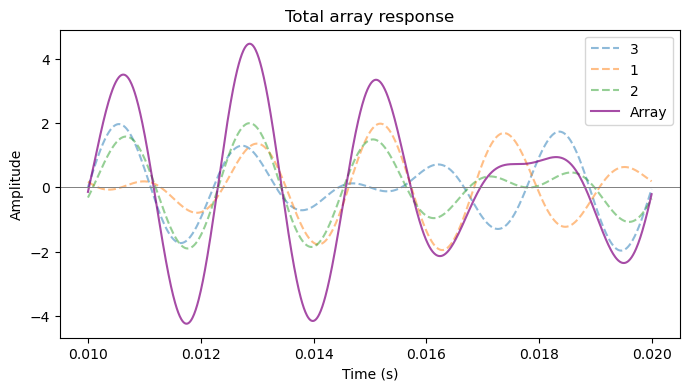

In [28]:
# Total array response
sig3 = siga1[2] + siga2[2]
sig2a = siga1[1] + siga2[1]
sig1a = siga1[0] + siga2[0]
sig = sig1a + sig2a + sig3

freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)

fig, ax = plt.subplots(figsize = (8, 4))

ax.plot(samples[tpi:tpf], sig3[tpi:tpf], label = '3', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = '1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = '2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig[tpi:tpf], label = 'Array', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# ax.set_ylim([-1.5, 1.5])
ax.axhline(0, color = 'grey', lw = 0.7)
ax.set_title(f'Total array response')
# fig.savefig('DF_recordings.png')

## 2. Fourier Transform each mic recording, separate out the phase and amplitude info

In [50]:
for i, sig in enumerate([sig1a, sig2a, sig3]):
    df = pd.DataFrame(sig, samples).rename(columns = {0:'Signal'})
    df.index.name = 'time'
    df.to_csv(f'Signal_{i + 1}.csv')

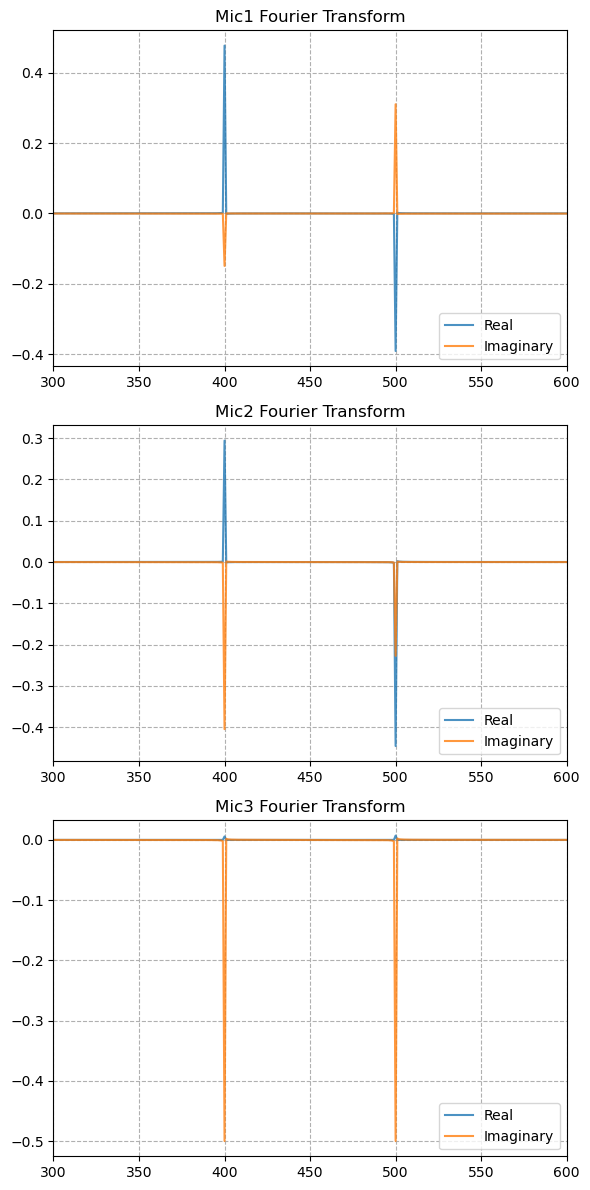

In [108]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6, 12))
for i, ax in enumerate(axs):
    filename = f'FFT_{i+1}.csv'
    dff = pd.read_csv(filename)
    dff = dff.rename(columns = {'Img: unnamed':'Img', 'Real: unnamed':'Re'})
    ax.plot(dff['Frequency (/s)'], dff['Re'], label = 'Real', alpha = 0.8)
    ax.plot(dff['Frequency (/s)'], dff['Img'], label = 'Imaginary', alpha = 0.8)
    ax.legend(loc='lower right')
    ax.set_xlim([300, 600])
    ax.set_title(f'Mic{i+1} Fourier Transform')
    ax.grid(visible=True, which='major', axis='both', ls = '--')
plt.tight_layout()
plt.show()

In [60]:
f400, f500 = [], []
for i in [1, 2, 3]:
    filename = f'FFT_{i}.csv'
    dff = pd.read_csv(filename)
    dff = dff.rename(columns = {'Img: unnamed':'Img', 'Real: unnamed':'Re'})
    ffv = []
    for ff in [400, 500]:
        re = dff[round(dff['Frequency (/s)'], 2) == ff]['Re'].values[0]
        img = dff[round(dff['Frequency (/s)'], 2) == ff]['Img'].values[0]
        ffv.append(re + 1j*img)
    f400.append(ffv[0])
    f500.append(ffv[1])

In [66]:
f400, f500

([(0.4773546376155132-0.1494739795049833j),
  (0.2939637091683839-0.4045748604041971j),
  (0.0057119429572237-0.4999744247432887j)],
 [(-0.3914859032804687+0.3104584855262453j),
  (-0.4454106747721985-0.2270508393905904j),
  (0.0071391770496026-0.499909556638633j)])

## 3. Steering: Frequency domain